<a href="https://www.kaggle.com/code/jeffbutt/cifake-cnn-resnet-prototype?scriptVersionId=322160973" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# CIFAKE: Real vs AI-Generated Image Detection (CNN / ResNet-Style Classifier
**Strong app-prototype version**

This notebook trains and evaluates a real-vs-AI image classifier on the CIFAKE dataset. It is designed as a precursor to a deployable app, so it emphasizes:

- clean dataset manifest creation
- **stratified validation splitting**
- baseline-vs-ResNet comparison
- validation-based threshold tuning
- test-set evaluation only after model selection
- saved model artifacts
- app-ready prediction helper functions

> **Important**: This is a prototype trained on CIFAKE-style 32×32 images. It should not be treated as a general-purpose deepfake detector for arbitrary internet images, screenshots, portraits, memes, or heavily compressed media.  

## 1. Setup 
This section imports the libraries used throughout the notebook and fixes random seeds for repeatability.

In [1]:
import os
import json
import random
import shutil
from pathlib import Path
from collections import Counter

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
from PIL import Image

In [4]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

2026-05-26 00:55:43.796426: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779756944.008104      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779756944.063506      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779756944.591485      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779756944.591527      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779756944.591530      57 computation_placer.cc:177] computation placer alr

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
)

In [6]:
print("TensorFlow:", tf.__version__)

TensorFlow: 2.19.0


## 2. Configuration
The path below is hard-coded for Kaggle. Change only if Kaggle mounts the dataset under a different directory.

In [7]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [8]:
# Kaggle dataset path
DATASET_DIR = Path("/kaggle/input/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images")

TRAIN_DIR = DATASET_DIR / "train"
TEST_DIR = DATASET_DIR / "test"

WORK_DIR = Path("/kaggle/working")
MODEL_DIR = WORK_DIR / "models"
REPORT_DIR = WORK_DIR / "reports"
PRED_DIR = WORK_DIR / "predictions"

for d in [MODEL_DIR, REPORT_DIR, PRED_DIR]:
    d.mkdir(parents=True, exist_ok=True)

In [9]:
# CIFAKE images are natively 32x32.
IMG_SIZE = 32
BATCH_SIZE = 256
VALIDATION_SPLIT = 0.10

In [10]:
# Keep these reasonable for Kaggle GPU. Increase if you want to push performance.
SIMPLE_CNN_EPOCHS = 10
RESNET_EPOCHS = 30

In [11]:
# Run both models so the notebook can prove whether the ResNet-style model adds value.
RUN_SIMPLE_CNN_BASELINE = True
RUN_RESNET_MODEL = True

In [12]:
# Optional test-time augmentation. Leave off for the main clean evaluation.
RUN_TTA = False

In [13]:
AUTOTUNE = tf.data.AUTOTUNE
CLASS_NAMES = ["REAL", "FAKE"]
LABEL_TO_ID = {"REAL": 0, "FAKE": 1}
ID_TO_LABEL = {0: "REAL", 1: "FAKE"}

In [14]:
print("Dataset directory:", DATASET_DIR)
print("Train directory exists:", TRAIN_DIR.exists())
print("Test directory exists:", TEST_DIR.exists())

Dataset directory: /kaggle/input/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images
Train directory exists: True
Test directory exists: True


## 3. GPU and Mixed Precision
Mixed precision is useful on modern Kaggle GPUs. The output layer is kept as `float32` to avoid numerical issues with binary probabilities.

In [15]:
gpus = tf.config.list_physical_devices("GPU")

if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU memory growth enabled.")
    except Exception as e:
        print("Could not set memory growth:", e)

    try:
        from tensorflow.keras import mixed_precision
        mixed_precision.set_global_policy("mixed_float16")
        print("Mixed precision enabled:", mixed_precision.global_policy())
    except Exception as e:
        print("Mixed precision not enabled:", e)
else:
    print("No GPU found. This notebook will run more slowly on CPU.")

GPU memory growth enabled.
Mixed precision enabled: <DTypePolicy "mixed_float16">


## 4. Build Manifest 
Instead of relying on `image_dataset_from_directory(... validation_split=...)`, this notebook creates an explicit manifest and then performs a **stratified** train/validation split.

This avoids the common failure where the validation split accidentally contains only one class.

In [16]:
def build_manifest(split_name, directory):
    rows = []
    valid_exts = ["*.jpg", "*.jpeg", "*.png", "*.bmp", "*.webp"]
    
    if not directory.exists():
        raise FileNotFoundError(f"Directory not found: {directory}")
    
    for class_dir in sorted(directory.iterdir()):
        if not class_dir.is_dir():
            continue
        
        label = class_dir.name.upper()
        if label not in LABEL_TO_ID:
            print(f"Skipping unexpected class folder: {class_dir}")
            continue
        
        for ext in valid_exts:
            for path in class_dir.glob(ext):
                rows.append({
                    "source_split": split_name,
                    "label": label,
                    "label_id": LABEL_TO_ID[label],
                    "path": str(path)
                })
    
    return pd.DataFrame(rows)

In [17]:
train_full_df = build_manifest("train", TRAIN_DIR)
test_df = build_manifest("test", TEST_DIR)

df = pd.concat([train_full_df, test_df], ignore_index=True)

print("Full manifest shape:", df.shape)
display(df.head())
print("\nCounts by source split and label:")
display(pd.crosstab(df["source_split"], df["label"]))

Full manifest shape: (120000, 4)


,source_split,label,label_id,path
0,train,FAKE,1,/kaggle/input/datasets/birdy654/cifake-real-an...
1,train,FAKE,1,/kaggle/input/datasets/birdy654/cifake-real-an...
2,train,FAKE,1,/kaggle/input/datasets/birdy654/cifake-real-an...
3,train,FAKE,1,/kaggle/input/datasets/birdy654/cifake-real-an...
4,train,FAKE,1,/kaggle/input/datasets/birdy654/cifake-real-an...



Counts by source split and label:


label,FAKE,REAL
source_split,,
test,10000,10000
train,50000,50000


## 5. Stratified Train/Validation Split 
The validation set must contain both REAL and FAKE images.  This corrects a serious error from the prior version, where the entire validation was FAKE images.  This ensures that there is a proper mix.  

In [18]:
train_df, val_df = train_test_split(
    train_full_df,
    test_size=VALIDATION_SPLIT,
    stratify=train_full_df["label_id"],
    random_state=SEED,
    shuffle=True,
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

split_summary = pd.DataFrame({
    "train": train_df["label"].value_counts().sort_index(),
    "validation": val_df["label"].value_counts().sort_index(),
    "test": test_df["label"].value_counts().sort_index(),
}).fillna(0).astype(int)

display(split_summary)

for name, part in [("train", train_df), ("validation", val_df), ("test", test_df)]:
    labels_present = sorted(part["label_id"].unique().tolist())
    assert labels_present == [0, 1], f"{name} split is invalid. It does not contain both classes: {labels_present}"

print("All splits contain both classes.")

,train,validation,test
label,,,
FAKE,45000,5000,10000
REAL,45000,5000,10000


All splits contain both classes.


## 6. Basic EDA
This section checks the class balance and a small sample of images.  We scaled back from the prior notebook, since this is the most important thing in this dataset.  When using a different dataset, it is recommended that you re-expand the EDA section to explore the dataset fully. 

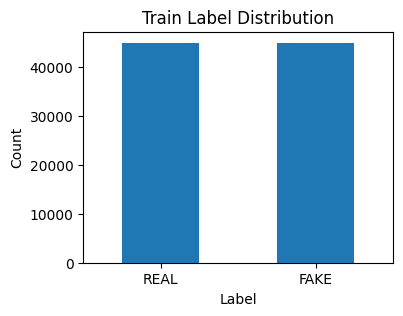

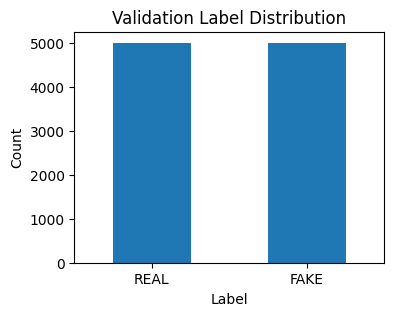

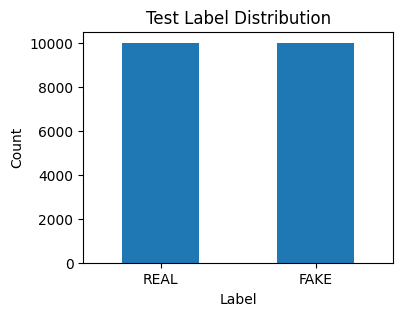

In [19]:
def plot_label_counts(dataframes):
    for name, part in dataframes.items():
        counts = part["label"].value_counts().reindex(CLASS_NAMES)
        plt.figure(figsize=(4, 3))
        counts.plot(kind="bar")
        plt.title(f"{name} Label Distribution")
        plt.xlabel("Label")
        plt.ylabel("Count")
        plt.xticks(rotation=0)
        plt.show()

plot_label_counts({"Train": train_df, "Validation": val_df, "Test": test_df})

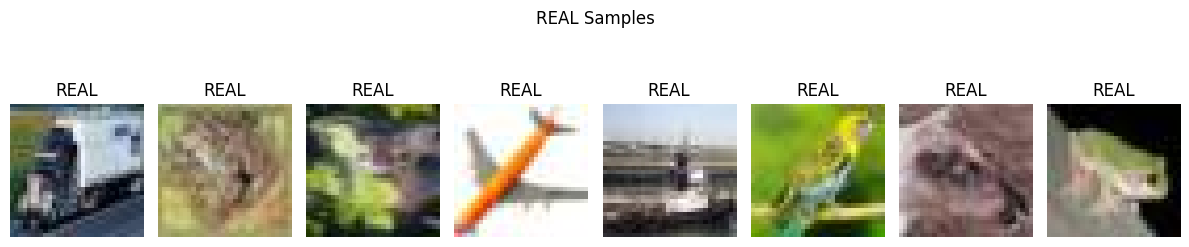

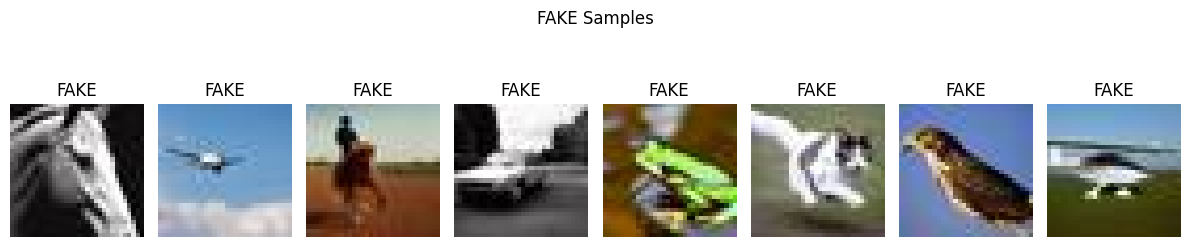

In [20]:
def show_sample_images(part, n=8, title="Sample Images"):
    sample = part.sample(n=min(n, len(part)), random_state=SEED)
    plt.figure(figsize=(12, 3))
    
    for i, (_, row) in enumerate(sample.iterrows(), start=1):
        img = Image.open(row["path"]).convert("RGB")
        plt.subplot(1, len(sample), i)
        plt.imshow(img)
        plt.title(row["label"])
        plt.axis("off")
    
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

show_sample_images(train_df[train_df["label"] == "REAL"], n=8, title="REAL Samples")
show_sample_images(train_df[train_df["label"] == "FAKE"], n=8, title="FAKE Samples")

## 7. TensorFlow Dataset Pipeline

The model receives `float32` images scaled to `[0, 1]`. Augmentation is placed inside the model so it only runs during training.

In [21]:
def decode_image(path, label):
    img_bytes = tf.io.read_file(path)
    img = tf.io.decode_image(img_bytes, channels=3, expand_animations=False)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32) / 255.0
    label = tf.cast(label, tf.float32)
    return img, label

In [22]:
def make_dataset(part, batch_size=BATCH_SIZE, shuffle=False):
    paths = part["path"].values
    labels = part["label_id"].values.astype(np.float32)
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    
    if shuffle:
        ds = ds.shuffle(buffer_size=len(part), seed=SEED, reshuffle_each_iteration=True)
    
    ds = ds.map(decode_image, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size)
    ds = ds.prefetch(AUTOTUNE)
    return ds

In [23]:
train_ds = make_dataset(train_df, shuffle=True)
val_ds = make_dataset(val_df, shuffle=False)
test_ds = make_dataset(test_df, shuffle=False)

for images, labels in train_ds.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)
    print("Image dtype:", images.dtype)
    print("Label dtype:", labels.dtype)
    print("Pixel range:", float(tf.reduce_min(images)), float(tf.reduce_max(images)))

I0000 00:00:1779756976.073827      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Image batch shape: (256, 32, 32, 3)
Label batch shape: (256,)
Image dtype: <dtype: 'float32'>
Label dtype: <dtype: 'float32'>
Pixel range: 0.0 1.0


## 8. Data Augmentation 
For CIFAKE, aggressive augmentation can hurt because subtle generation artifacts may matter. This uses light augmentation only.

In [24]:
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomTranslation(0.05, 0.05),
        layers.RandomZoom(0.05),
    ],
    name="light_augmentation"
)

## 9. Build Model 

Two models are used:

1. **Simple CNN baseline** proves whether a basic model is already strong.
2. **Small ResNet-style CNN** stronger architecture with residual blocks.

The notebook selects the model using validation metrics, then reports final test performance once.

In [35]:
def build_simple_cnn(img_size=32):
    inputs = keras.Input(shape=(img_size, img_size, 3))
    x = data_augmentation(inputs)
    
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    
    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling2D()(x)
    
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.35)(x)
    outputs = layers.Dense(1, activation="sigmoid", dtype="float32")(x)
    
    return keras.Model(inputs, outputs, name="simple_cnn_cifake")

In [36]:
def residual_block(x, filters, stride=1, dropout_rate=0.0):
    shortcut = x
    
    x = layers.Conv2D(filters, 3, strides=stride, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    
    x = layers.Conv2D(filters, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    
    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, strides=stride, padding="same", use_bias=False)(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)
    
    x = layers.Add()([x, shortcut])
    x = layers.Activation("relu")(x)
    
    if dropout_rate > 0:
        x = layers.Dropout(dropout_rate)(x)
    
    return x

In [37]:
def build_small_resnet(img_size=32):
    inputs = keras.Input(shape=(img_size, img_size, 3))
    x = data_augmentation(inputs)
    
    x = layers.Conv2D(64, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    
    x = residual_block(x, 64, stride=1, dropout_rate=0.05)
    x = residual_block(x, 64, stride=1, dropout_rate=0.05)
    
    x = residual_block(x, 128, stride=2, dropout_rate=0.10)
    x = residual_block(x, 128, stride=1, dropout_rate=0.10)
    
    x = residual_block(x, 256, stride=2, dropout_rate=0.15)
    x = residual_block(x, 256, stride=1, dropout_rate=0.15)
    
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.40)(x)
    outputs = layers.Dense(1, activation="sigmoid", dtype="float32")(x)
    
    return keras.Model(inputs, outputs, name="small_resnet_cifake")

## 10. Training Utilities

Callbacks monitor validation AUC. This is now valid because the validation set contains both classes.

In [38]:
def compile_binary_model(model, learning_rate=1e-3):
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=[
            keras.metrics.BinaryAccuracy(name="accuracy"),
            keras.metrics.AUC(name="auc"),
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall"),
        ],
    )
    return model

In [39]:
def make_callbacks(model_name):
    checkpoint_path = MODEL_DIR / f"{model_name}_best.keras"
    return [
        keras.callbacks.ModelCheckpoint(
            filepath=str(checkpoint_path),
            monitor="val_auc",
            mode="max",
            save_best_only=True,
            verbose=1,
        ),
        keras.callbacks.EarlyStopping(
            monitor="val_auc",
            mode="max",
            patience=5,
            min_delta=0.0005,
            restore_best_weights=True,
            verbose=1
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            mode="min",
            factor=0.3,
            patience=2,
            min_delta=0.0005,
            min_lr=1e-6,
            verbose=1
        ),
    ]

In [40]:
def plot_history(history, title_prefix="Model"):
    hist = pd.DataFrame(history.history)
    display(hist.tail())
    
    for metric in ["loss", "accuracy", "auc"]:
        plt.figure(figsize=(7, 4))
        plt.plot(hist[metric], label=f"train_{metric}")
        val_metric = f"val_{metric}"
        if val_metric in hist:
            plt.plot(hist[val_metric], label=val_metric)
        plt.title(f"{title_prefix}: {metric}")
        plt.xlabel("Epoch")
        plt.ylabel(metric)
        plt.legend()
        plt.show()

## 9. Data Augmentation 
For 32x32 images, augmentation must be moderate.

Good augmentations:
* horizontal flip
* small translation
* small rotation
* slight zoom
* slight contrast shift

Avoid aggressive crops because the images are already tiny.

In [41]:
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomTranslation(height_factor=0.08, width_factor=0.08),
        layers.RandomRotation(0.05),
        layers.RandomZoom(0.08),
        layers.RandomContrast(0.10),
    ],
    name="data_augmentation"
)

## 11. Train Simple CNN Baseline

This baseline is important. We should not jump straight to the more complex model without proving it is needed.

Model: "simple_cnn_cifake"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,785 (432.75 KB)

 Trainable params: 110,337 (431.00 KB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/10
351/352 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.7864 - auc: 0.8703 - loss: 0.4402 - precision: 0.7975 - recall: 0.7656
Epoch 1: val_auc improved from -inf to 0.80343, saving model to /kaggle/working/models/simple_cnn_cifake_best.keras
352/352 ━━━━━━━━━━━━━━━━━━━━ 26s 60ms/step - accuracy: 0.7866 - auc: 0.8705 - loss: 0.4398 - precision: 0.7977 - recall: 0.7659 - val_accuracy: 0.7204 - val_auc: 0.8034 - val_loss: 0.5965 - val_precision: 0.7091 - val_recall: 0.7474 - learning_rate: 0.0010
Epoch 2/10
351/352 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.8824 - auc: 0.9508 - loss: 0.2838 - precision: 0.8859 - recall: 0.8767
Epoch 2: val_auc improved from 0.80343 to 0.96888, saving model to /kaggle/working/models/simple_cnn_cifake_best.keras
352/352 ━━━━━━━━━━━━━━━━━━━━ 20s 57ms/step - accuracy: 0.8824 - auc: 0.9508 - loss: 0.2838 - precision: 0.8859 - recall: 0.8767 - val_accuracy: 0.7621 - val_auc: 0.9689 - val_loss: 0.5703 - val_precision: 0.6787 - val_recall: 0.9954

,accuracy,auc,loss,precision,recall,val_accuracy,val_auc,val_loss,val_precision,val_recall,learning_rate
5,0.925000,0.978648,0.186748,0.924868,0.925156,0.9087,0.978433,0.226346,0.865237,0.9682,0.00030
6,0.928256,0.980298,0.178889,0.929697,0.926578,0.7827,0.969877,0.613587,0.697886,0.9970,0.00030
7,0.931611,0.981719,0.172115,0.933045,0.929956,0.8778,0.982455,0.295994,0.809368,0.9884,0.00030
8,0.936067,0.983769,0.161953,0.936455,0.935622,0.8645,0.982126,0.332640,0.791460,0.9898,0.00009
9,0.937267,0.984000,0.160678,0.937967,0.936467,0.8721,0.982061,0.325227,0.800323,0.9916,0.00009


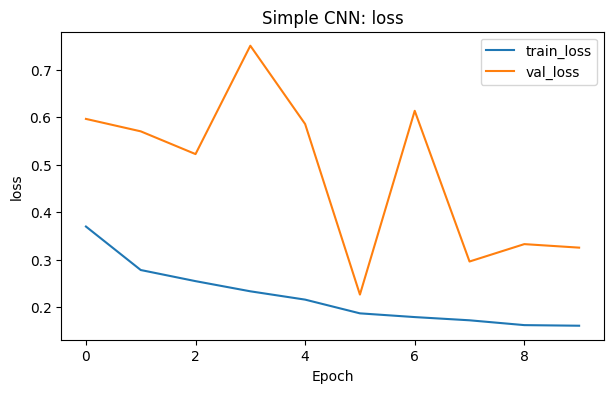

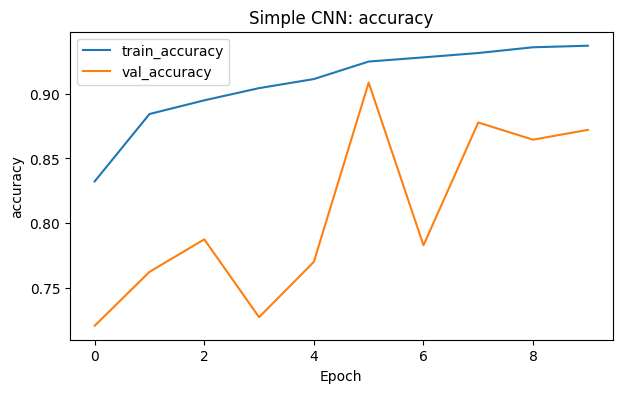

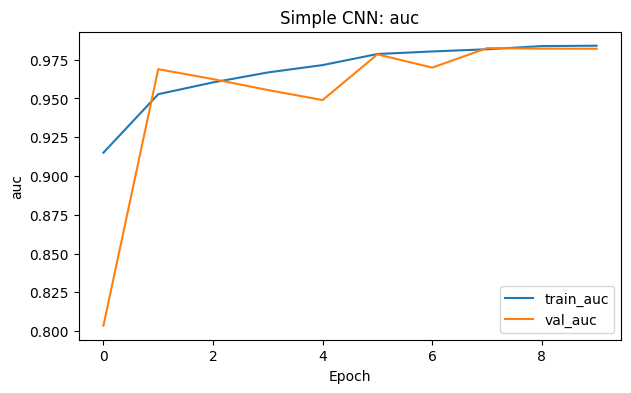

In [42]:
trained_models = {}
histories = {}

if RUN_SIMPLE_CNN_BASELINE:
    simple_cnn = build_simple_cnn(IMG_SIZE)
    compile_binary_model(simple_cnn, learning_rate=1e-3)
    simple_cnn.summary()
    
    simple_history = simple_cnn.fit(
        train_ds,
        validation_data=val_ds,
        epochs=SIMPLE_CNN_EPOCHS,
        callbacks=make_callbacks("simple_cnn_cifake"),
        verbose=1,
    )
    
    histories["simple_cnn"] = simple_history
    trained_models["simple_cnn"] = keras.models.load_model(MODEL_DIR / "simple_cnn_cifake_best.keras")
    plot_history(simple_history, title_prefix="Simple CNN")
else:
    print("Simple CNN baseline skipped.")

## 12. Train Small ResNet-Style CNN

The ResNet-style model is the main candidate for the app prototype.

Model: "small_resnet_cifake"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 32, 32, 3) │          0 │ input_layer_6[0]… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_24 (Conv2D)  │ (None, 32, 32,    │      1,728 │ data_augmentatio… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_24[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_13       │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_25 (Conv2D)  │ (None, 32, 32,    │     36,864 │ activation_13[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_25[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_14       │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_26 (Conv2D)  │ (None, 32, 32,    │     36,864 │ activation_14[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_26[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_6 (Add)         │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │ activation_13[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_15       │ (None, 32, 32,    │          0 │ add_6[0][0]       │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_10          │ (None, 32, 32,    │          0 │ activation_15[0]… │
│ (Dropout)           │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_27 (Conv2D)  │ (None, 32, 32,    │     36,864 │ dropout_10[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_27[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_16       │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_28 (Conv2D)  │ (None, 32, 32,    │     36,864 │ activation_16[0]

 Total params: 2,846,657 (10.86 MB)

 Trainable params: 2,841,665 (10.84 MB)

 Non-trainable params: 4,992 (19.50 KB)

Epoch 1/30


E0000 00:00:1779758038.308815      57 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/small_resnet_cifake_1/dropout_10_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - accuracy: 0.7560 - auc: 0.8318 - loss: 0.5279 - precision: 0.7531 - recall: 0.7571
Epoch 1: val_auc improved from -inf to 0.73062, saving model to /kaggle/working/models/small_resnet_cifake_best.keras
352/352 ━━━━━━━━━━━━━━━━━━━━ 67s 159ms/step - accuracy: 0.7561 - auc: 0.8319 - loss: 0.5277 - precision: 0.7532 - recall: 0.7573 - val_accuracy: 0.5896 - val_auc: 0.7306 - val_loss: 0.9269 - val_precision: 0.5517 - val_recall: 0.9554 - learning_rate: 0.0010
Epoch 2/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - accuracy: 0.8665 - auc: 0.9397 - loss: 0.3139 - precision: 0.8624 - recall: 0.8706
Epoch 2: val_auc improved from 0.73062 to 0.95805, saving model to /kaggle/working/models/small_resnet_cifake_best.keras
352/352 ━━━━━━━━━━━━━━━━━━━━ 55s 156ms/step - accuracy: 0.8665 - auc: 0.9397 - loss: 0.3138 - precision: 0.8625 - recall: 0.8706 - val_accuracy: 0.7958 - val_auc: 0.9580 - val_loss: 0.4804 - val_precision: 0.7155 - val_recall: 0.9820 - 

,accuracy,auc,loss,precision,recall,val_accuracy,val_auc,val_loss,val_precision,val_recall,learning_rate
14,0.955889,0.991823,0.113617,0.956579,0.955133,0.9265,0.987248,0.195870,0.883612,0.9824,0.000027
15,0.957400,0.992152,0.110296,0.958092,0.956644,0.9160,0.987488,0.223073,0.863636,0.9880,0.000008
16,0.957978,0.992218,0.110139,0.958569,0.957333,0.9170,0.987495,0.221093,0.865277,0.9878,0.000008
17,0.958100,0.992155,0.110446,0.958416,0.957756,0.9197,0.987553,0.216142,0.869649,0.9874,0.000002
18,0.957589,0.992300,0.109911,0.958475,0.956622,0.9227,0.987885,0.207293,0.874668,0.9868,0.000002


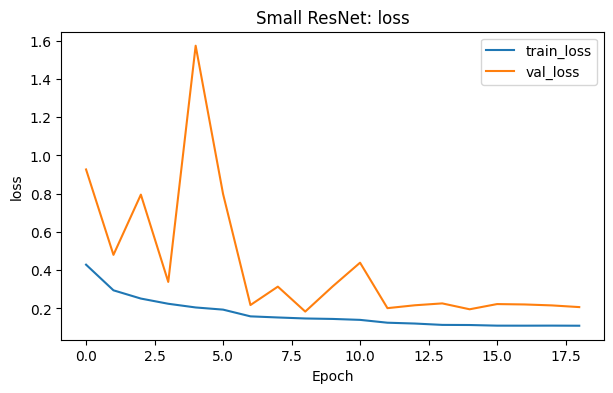

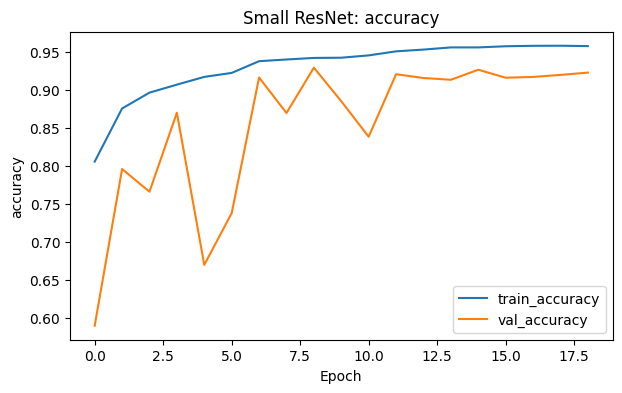

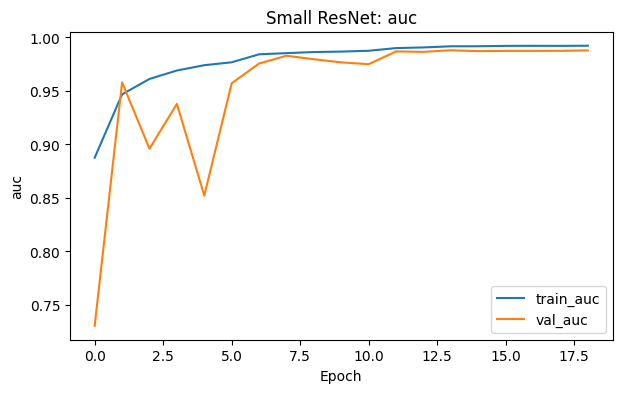

In [43]:
if RUN_RESNET_MODEL:
    small_resnet = build_small_resnet(IMG_SIZE)
    compile_binary_model(small_resnet, learning_rate=1e-3)
    small_resnet.summary()
    
    resnet_history = small_resnet.fit(
        train_ds,
        validation_data=val_ds,
        epochs=RESNET_EPOCHS,
        callbacks=make_callbacks("small_resnet_cifake"),
        verbose=1,
    )
    
    histories["small_resnet"] = resnet_history
    trained_models["small_resnet"] = keras.models.load_model(MODEL_DIR / "small_resnet_cifake_best.keras")
    plot_history(resnet_history, title_prefix="Small ResNet")
else:
    print("Small ResNet model skipped.")

## 13. Evaluation Helpers

All model comparison happens on validation data. The test set is held back for the final selected model.

In [44]:
def predict_dataset(model, dataset):
    y_true = []
    y_prob = []
    
    for images, labels in dataset:
        probs = model.predict(images, verbose=0).reshape(-1)
        y_prob.extend(probs.tolist())
        y_true.extend(labels.numpy().reshape(-1).tolist())
    
    return np.array(y_true).astype(int), np.array(y_prob)

In [45]:
def safe_roc_auc(y_true, y_prob):
    if len(np.unique(y_true)) < 2:
        return np.nan
    return roc_auc_score(y_true, y_prob)

In [46]:
def evaluate_predictions(y_true, y_prob, threshold=0.5, label="Evaluation", verbose=True):
    y_pred = (y_prob >= threshold).astype(int)
    
    metrics = {
        "label": label,
        "threshold": float(threshold),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "roc_auc": float(safe_roc_auc(y_true, y_prob)),
    }
    
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    
    if verbose:
        print("=" * 80)
        print(label)
        print("=" * 80)
        for k, v in metrics.items():
            if isinstance(v, float):
                print(f"{k}: {v:.4f}")
            else:
                print(f"{k}: {v}")
        
        print("\nClassification Report:")
        print(classification_report(
            y_true,
            y_pred,
            labels=[0, 1],
            target_names=CLASS_NAMES,
            zero_division=0,
        ))
        print("Confusion Matrix:")
        print(cm)
    
    return metrics, cm

## 14. Validation Comparison

This section compares trained models using validation metrics at the default `0.50` threshold.

In [47]:
val_predictions = {}
val_comparison_rows = []

for model_name, model in trained_models.items():
    y_true, y_prob = predict_dataset(model, val_ds)
    val_predictions[model_name] = {"y_true": y_true, "y_prob": y_prob}
    metrics, _ = evaluate_predictions(
        y_true,
        y_prob,
        threshold=0.5,
        label=f"Validation: {model_name} at 0.50",
        verbose=False,
    )
    metrics["model_name"] = model_name
    val_comparison_rows.append(metrics)

val_comparison_df = pd.DataFrame(val_comparison_rows).sort_values("roc_auc", ascending=False)
display(val_comparison_df)

best_model_name = val_comparison_df.iloc[0]["model_name"]
best_model = trained_models[best_model_name]

print("Selected model based on validation ROC AUC:", best_model_name)

,label,threshold,accuracy,precision,recall,f1,roc_auc,model_name
1,Validation: small_resnet at 0.50,0.5,0.9133,0.859579,0.9880,0.919326,0.989778,small_resnet
0,Validation: simple_cnn at 0.50,0.5,0.8778,0.809368,0.9884,0.889969,0.983626,simple_cnn


Selected model based on validation ROC AUC: small_resnet


## 15. Threshold Tuning on Validation Set

The threshold is tuned only on validation data. The test set is not used for threshold selection.

For an app, you may prefer a threshold that balances false positives and false negatives differently. This notebook selects by F1 as a default.

In [48]:
val_y_true = val_predictions[best_model_name]["y_true"]
val_y_prob = val_predictions[best_model_name]["y_prob"]

thresholds = np.linspace(0.05, 0.95, 181)
threshold_rows = []

for threshold in thresholds:
    y_pred = (val_y_prob >= threshold).astype(int)
    threshold_rows.append({
        "threshold": float(threshold),
        "accuracy": float(accuracy_score(val_y_true, y_pred)),
        "precision": float(precision_score(val_y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(val_y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(val_y_true, y_pred, zero_division=0)),
    })

threshold_df = pd.DataFrame(threshold_rows)
threshold_df = threshold_df.sort_values("f1", ascending=False).reset_index(drop=True)

display(threshold_df.head(20))

best_threshold = float(threshold_df.iloc[0]["threshold"])
print("Best validation threshold by F1:", best_threshold)

# Save full threshold table for app/design review.
threshold_path = REPORT_DIR / "validation_threshold_search.csv"
threshold_df.to_csv(threshold_path, index=False)
print("Saved threshold table to:", threshold_path)

,threshold,accuracy,precision,recall,f1
0,0.900,0.9521,0.948601,0.9560,0.952286
1,0.895,0.9517,0.946079,0.9580,0.952002
2,0.905,0.9519,0.950010,0.9540,0.952001
3,0.890,0.9508,0.943876,0.9586,0.951181
4,0.910,0.9511,0.951010,0.9512,0.951105
5,0.880,0.9505,0.941753,0.9604,0.950985
6,0.875,0.9503,0.940348,0.9616,0.950855
7,0.885,0.9504,0.942436,0.9594,0.950842
8,0.915,0.9507,0.952419,0.9488,0.950606
9,0.870,0.9498,0.938915,0.9622,0.950415


Best validation threshold by F1: 0.8999999999999999
Saved threshold table to: /kaggle/working/reports/validation_threshold_search.csv


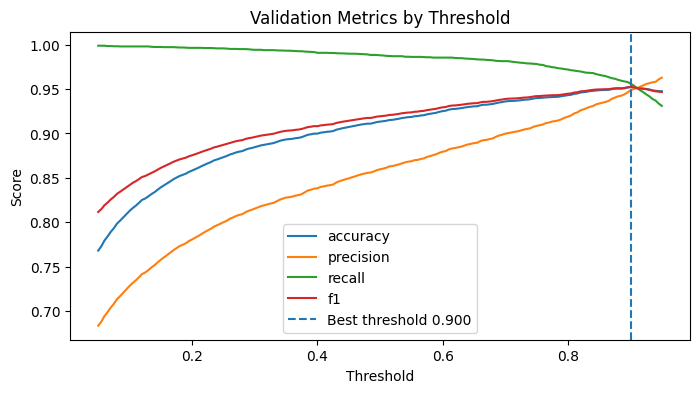

In [49]:
plt.figure(figsize=(8, 4))
for metric in ["accuracy", "precision", "recall", "f1"]:
    plot_df = threshold_df.sort_values("threshold")
    plt.plot(plot_df["threshold"], plot_df[metric], label=metric)

plt.axvline(best_threshold, linestyle="--", label=f"Best threshold {best_threshold:.3f}")
plt.title("Validation Metrics by Threshold")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.show()

## 16. Validation ROC and Precision-Recall Curves

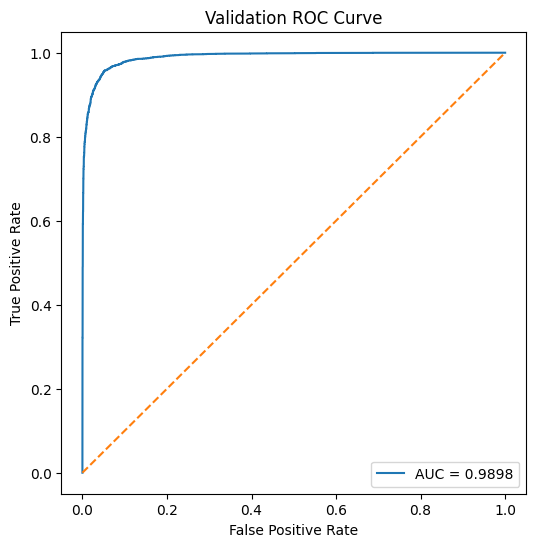

In [50]:
val_auc = safe_roc_auc(val_y_true, val_y_prob)

fpr, tpr, roc_thresholds = roc_curve(val_y_true, val_y_prob)
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"AUC = {val_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("Validation ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

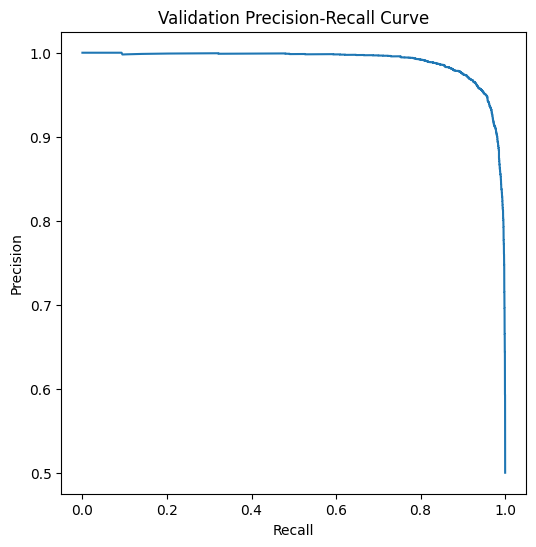

In [51]:
precision, recall, pr_thresholds = precision_recall_curve(val_y_true, val_y_prob)
plt.figure(figsize=(6, 6))
plt.plot(recall, precision)
plt.title("Validation Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

## 17. Final Test Evaluation

The test set is used here, after model selection and threshold tuning are complete.

In [52]:
test_y_true, test_y_prob = predict_dataset(best_model, test_ds)

test_metrics_05, test_cm_05 = evaluate_predictions(
    test_y_true,
    test_y_prob,
    threshold=0.5,
    label=f"Test: {best_model_name} at 0.50 Threshold",
)

test_metrics_tuned, test_cm_tuned = evaluate_predictions(
    test_y_true,
    test_y_prob,
    threshold=best_threshold,
    label=f"Test: {best_model_name} at Tuned Threshold {best_threshold:.3f}",
)

Test: small_resnet at 0.50 Threshold
label: Test: small_resnet at 0.50 Threshold
threshold: 0.5000
accuracy: 0.9141
precision: 0.8596
recall: 0.9897
f1: 0.9201
roc_auc: 0.9900

Classification Report:
              precision    recall  f1-score   support

        REAL       0.99      0.84      0.91     10000
        FAKE       0.86      0.99      0.92     10000

    accuracy                           0.91     20000
   macro avg       0.92      0.91      0.91     20000
weighted avg       0.92      0.91      0.91     20000

Confusion Matrix:
[[8384 1616]
 [ 103 9897]]
Test: small_resnet at Tuned Threshold 0.900
label: Test: small_resnet at Tuned Threshold 0.900
threshold: 0.9000
accuracy: 0.9518
precision: 0.9485
recall: 0.9555
f1: 0.9520
roc_auc: 0.9900

Classification Report:
              precision    recall  f1-score   support

        REAL       0.96      0.95      0.95     10000
        FAKE       0.95      0.96      0.95     10000

    accuracy                           0.95     20

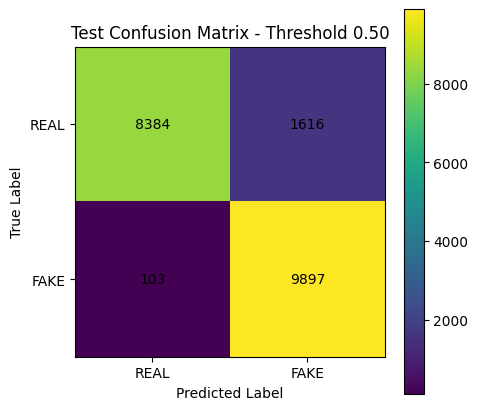

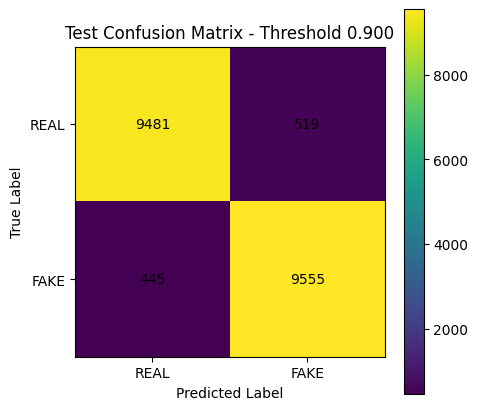

In [53]:
def plot_confusion_matrix(cm, title):
    plt.figure(figsize=(5, 5))
    plt.imshow(cm)
    plt.title(title)
    plt.colorbar()
    
    tick_marks = np.arange(len(CLASS_NAMES))
    plt.xticks(tick_marks, CLASS_NAMES)
    plt.yticks(tick_marks, CLASS_NAMES)
    
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, format(cm[i, j], "d"), ha="center", va="center")
    
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.show()

plot_confusion_matrix(test_cm_05, "Test Confusion Matrix - Threshold 0.50")
plot_confusion_matrix(test_cm_tuned, f"Test Confusion Matrix - Threshold {best_threshold:.3f}")

## 18. Probability Distribution

This plot helps show how separable the model thinks the two classes are.

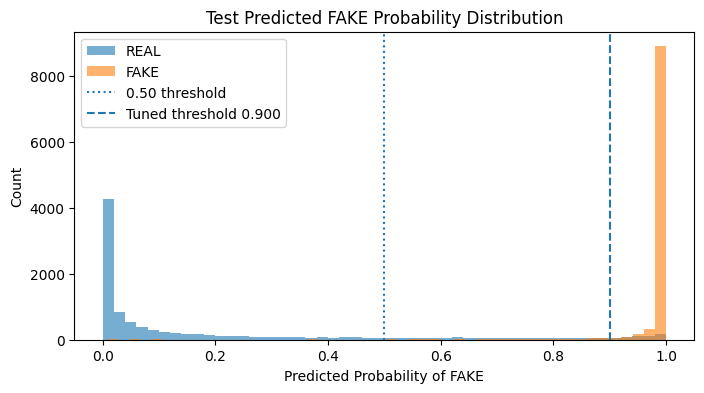

In [54]:
plt.figure(figsize=(8, 4))
plt.hist(test_y_prob[test_y_true == 0], bins=50, alpha=0.6, label="REAL")
plt.hist(test_y_prob[test_y_true == 1], bins=50, alpha=0.6, label="FAKE")
plt.axvline(0.5, linestyle=":", label="0.50 threshold")
plt.axvline(best_threshold, linestyle="--", label=f"Tuned threshold {best_threshold:.3f}")
plt.title("Test Predicted FAKE Probability Distribution")
plt.xlabel("Predicted Probability of FAKE")
plt.ylabel("Count")
plt.legend()
plt.show()

## 19. Prediction DataFrame and Error Analysis

This section saves row-level predictions and shows the most confident mistakes.

In [55]:
test_results_df = test_df.copy()
test_results_df["true_label_numeric"] = test_y_true
test_results_df["pred_fake_probability"] = test_y_prob
test_results_df["pred_label_numeric"] = (test_results_df["pred_fake_probability"] >= best_threshold).astype(int)
test_results_df["pred_label"] = test_results_df["pred_label_numeric"].map(ID_TO_LABEL)
test_results_df["correct"] = test_results_df["true_label_numeric"] == test_results_df["pred_label_numeric"]

test_results_df["confidence"] = np.where(
    test_results_df["pred_label_numeric"] == 1,
    test_results_df["pred_fake_probability"],
    1 - test_results_df["pred_fake_probability"],
)

test_predictions_path = PRED_DIR / "test_predictions.csv"
test_results_df.to_csv(test_predictions_path, index=False)
print("Saved test predictions to:", test_predictions_path)

display(test_results_df.head())

Saved test predictions to: /kaggle/working/predictions/test_predictions.csv


,source_split,label,label_id,path,true_label_numeric,pred_fake_probability,pred_label_numeric,pred_label,correct,confidence
0,test,FAKE,1,/kaggle/input/datasets/birdy654/cifake-real-an...,1,0.999809,1,FAKE,True,0.999809
1,test,FAKE,1,/kaggle/input/datasets/birdy654/cifake-real-an...,1,0.999999,1,FAKE,True,0.999999
2,test,FAKE,1,/kaggle/input/datasets/birdy654/cifake-real-an...,1,0.997330,1,FAKE,True,0.997330
3,test,FAKE,1,/kaggle/input/datasets/birdy654/cifake-real-an...,1,0.957562,1,FAKE,True,0.957562
4,test,FAKE,1,/kaggle/input/datasets/birdy654/cifake-real-an...,1,0.990898,1,FAKE,True,0.990898


In [56]:
mistakes_df = test_results_df[~test_results_df["correct"]].copy()
correct_df = test_results_df[test_results_df["correct"]].copy()

print("Mistakes:", len(mistakes_df))
print("Correct:", len(correct_df))

display(mistakes_df.sort_values("confidence", ascending=False).head(20))

Mistakes: 964
Correct: 19036


,source_split,label,label_id,path,true_label_numeric,pred_fake_probability,pred_label_numeric,pred_label,correct,confidence
15166,test,REAL,0,/kaggle/input/datasets/birdy654/cifake-real-an...,0,0.999982,1,FAKE,False,0.999982
16425,test,REAL,0,/kaggle/input/datasets/birdy654/cifake-real-an...,0,0.999959,1,FAKE,False,0.999959
12956,test,REAL,0,/kaggle/input/datasets/birdy654/cifake-real-an...,0,0.999927,1,FAKE,False,0.999927
19676,test,REAL,0,/kaggle/input/datasets/birdy654/cifake-real-an...,0,0.999887,1,FAKE,False,0.999887
16842,test,REAL,0,/kaggle/input/datasets/birdy654/cifake-real-an...,0,0.999747,1,FAKE,False,0.999747
15899,test,REAL,0,/kaggle/input/datasets/birdy654/cifake-real-an...,0,0.999707,1,FAKE,False,0.999707
14790,test,REAL,0,/kaggle/input/datasets/birdy654/cifake-real-an...,0,0.999692,1,FAKE,False,0.999692
14587,test,REAL,0,/kaggle/input/datasets/birdy654/cifake-real-an...,0,0.999642,1,FAKE,False,0.999642
14883,test,REAL,0,/kaggle/input/datasets/birdy654/cifake-real-an...,0,0.999632,1,FAKE,False,0.999632
18732,test,REAL,0,/kaggle/input/datasets/birdy654/cifake-real-an...,0,0.999418,1,FAKE,False,0.999418


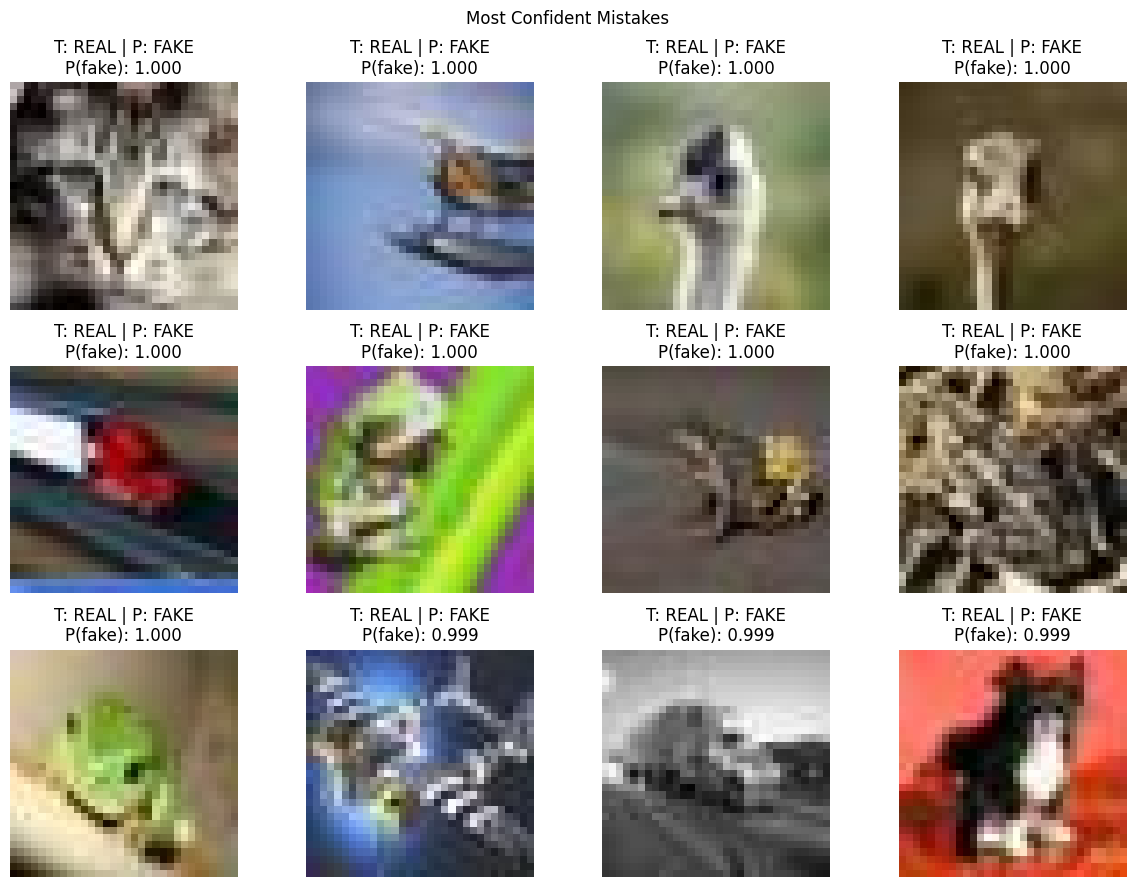

In [57]:
def show_prediction_grid(rows, title, n=12):
    rows = rows.head(n)
    if len(rows) == 0:
        print("No rows to display.")
        return
    
    cols = 4
    rows_n = int(np.ceil(len(rows) / cols))
    plt.figure(figsize=(12, 3 * rows_n))
    
    for i, (_, row) in enumerate(rows.iterrows(), start=1):
        img = Image.open(row["path"]).convert("RGB")
        plt.subplot(rows_n, cols, i)
        plt.imshow(img)
        plt.title(
            f"T: {row['label']} | P: {row['pred_label']}\nP(fake): {row['pred_fake_probability']:.3f}"
        )
        plt.axis("off")
    
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

show_prediction_grid(
    mistakes_df.sort_values("confidence", ascending=False),
    title="Most Confident Mistakes",
    n=12,
)

## 20. Optional Test-Time Augmentation

TTA averages the original image and a horizontally flipped version. This should always be optional and not set as the default, so the main test result stays clean and easy to reproduce.

In [58]:
def predict_single_array(model, arr):
    arr = np.expand_dims(arr, axis=0)
    return float(model.predict(arr, verbose=0).reshape(-1)[0])

In [59]:
def predict_single_image_tta(model, image_path):
    img = Image.open(image_path).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
    arr = np.asarray(img).astype(np.float32) / 255.0
    prob_original = predict_single_array(model, arr)
    prob_flipped = predict_single_array(model, np.fliplr(arr))
    return (prob_original + prob_flipped) / 2

In [60]:
if RUN_TTA:
    tta_probs = []
    for i, path in enumerate(test_df["path"], start=1):
        tta_probs.append(predict_single_image_tta(best_model, path))
        if i % 1000 == 0:
            print(f"TTA predicted {i}/{len(test_df)}")
    
    tta_probs = np.array(tta_probs)
    evaluate_predictions(
        test_y_true,
        tta_probs,
        threshold=best_threshold,
        label=f"Test with TTA at Threshold {best_threshold:.3f}",
    )
else:
    print("TTA skipped.")

TTA skipped.


## 21. Grad-CAM Explainability

Grad-CAM is useful for sanity checking where the model is looking. For 32×32 images, interpret heatmaps carefully; they are coarse.

In [61]:
def find_last_conv_layer_name(model):
    for layer in reversed(model.layers):
        if isinstance(layer, layers.Conv2D):
            return layer.name
    return None

last_conv_layer_name = find_last_conv_layer_name(best_model)
print("Last Conv2D layer:", last_conv_layer_name)

Last Conv2D layer: conv2d_38


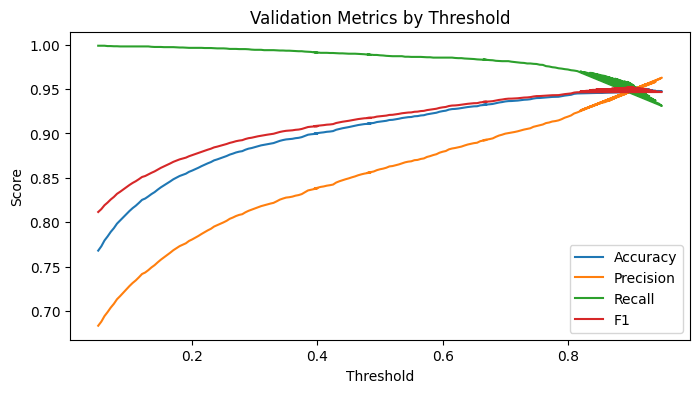

In [62]:
plt.figure(figsize=(8, 4))
plt.plot(threshold_df["threshold"], threshold_df["accuracy"], label="Accuracy")
plt.plot(threshold_df["threshold"], threshold_df["precision"], label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], label="Recall")
plt.plot(threshold_df["threshold"], threshold_df["f1"], label="F1")
plt.title("Validation Metrics by Threshold")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.show()

In [63]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    grad_model = keras.Model(
        model.inputs,
        [model.get_layer(last_conv_layer_name).output, model.output],
    )
    
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]
    
    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    
    max_value = tf.reduce_max(heatmap)
    if max_value == 0:
        return np.zeros_like(heatmap.numpy())
    
    heatmap = tf.maximum(heatmap, 0) / max_value
    return heatmap.numpy()


def load_image_for_model(path):
    img = Image.open(path).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
    arr = np.asarray(img).astype(np.float32) / 255.0
    arr = np.expand_dims(arr, axis=0)
    return img, arr


def show_gradcam(path, model, title="Grad-CAM"):
    if last_conv_layer_name is None:
        print("No Conv2D layer found for Grad-CAM.")
        return
    
    img, img_array = load_image_for_model(path)
    heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name)
    heatmap_resized = Image.fromarray(np.uint8(255 * heatmap)).resize((IMG_SIZE, IMG_SIZE))
    heatmap_resized = np.asarray(heatmap_resized)
    
    plt.figure(figsize=(9, 3))
    
    plt.subplot(1, 3, 1)
    plt.imshow(img)
    plt.title("Original")
    plt.axis("off")
    
    plt.subplot(1, 3, 2)
    plt.imshow(heatmap_resized)
    plt.title("Heatmap")
    plt.axis("off")
    
    plt.subplot(1, 3, 3)
    plt.imshow(img)
    plt.imshow(heatmap_resized, alpha=0.45)
    plt.title(title)
    plt.axis("off")
    
    plt.tight_layout()
    plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer_6']
Received: inputs=Tensor(shape=(1, 32, 32, 3))
  warnings.warn(msg)


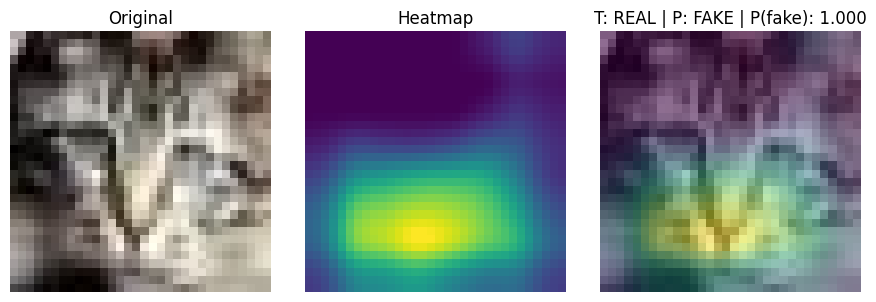

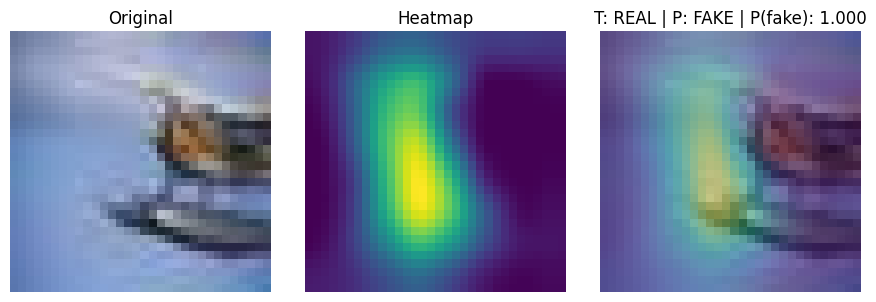

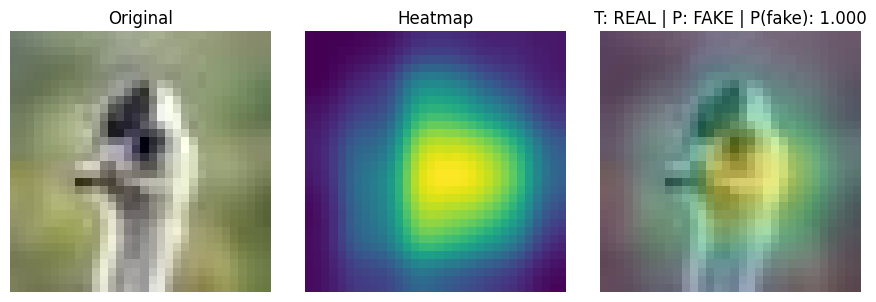

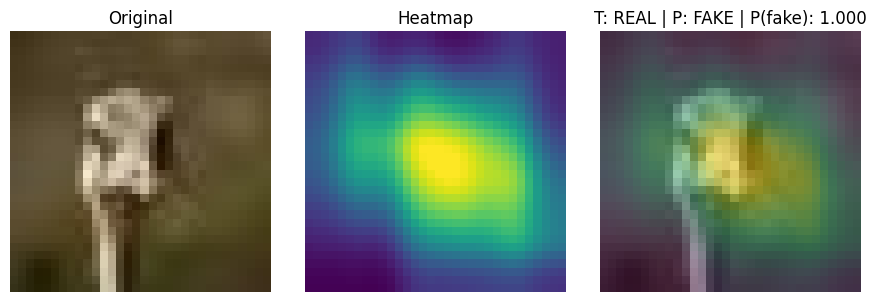

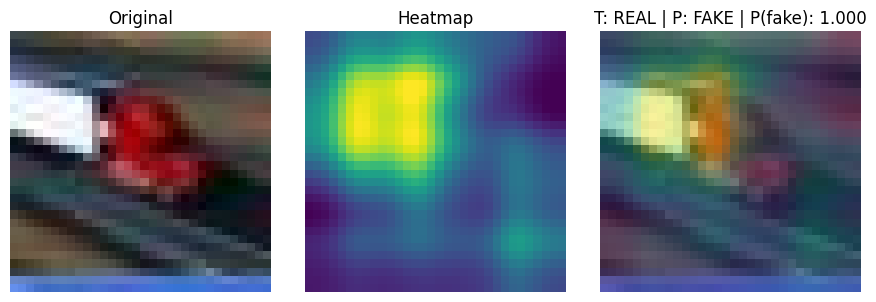

In [64]:
if last_conv_layer_name is not None:
    for _, row in mistakes_df.sort_values("confidence", ascending=False).head(5).iterrows():
        title = f"T: {row['label']} | P: {row['pred_label']} | P(fake): {row['pred_fake_probability']:.3f}"
        show_gradcam(row["path"], best_model, title=title)
else:
    print("Grad-CAM skipped.")

## 22. Save Model and Reports

The app needs both the model and the threshold/config metadata.

In [65]:
final_model_path = MODEL_DIR / "cifake_best_model_final.keras"
best_model.save(final_model_path)

app_config = {
    "dataset": "CIFAKE",
    "model_name": best_model_name,
    "model_path": str(final_model_path),
    "image_size": IMG_SIZE,
    "class_mapping": LABEL_TO_ID,
    "id_to_label": ID_TO_LABEL,
    "default_threshold": 0.5,
    "validation_tuned_threshold": best_threshold,
    "recommended_app_threshold": best_threshold,
    "important_warning": (
        "Prototype trained on CIFAKE-style 32x32 images. Not a general-purpose deepfake detector. "
        "Predictions on out-of-distribution images may be unreliable."
    ),
}

metrics_report = {
    "validation_comparison": val_comparison_df.to_dict(orient="records"),
    "selected_model": best_model_name,
    "test_at_0_5": test_metrics_05,
    "test_at_tuned_threshold": test_metrics_tuned,
    "app_config": app_config,
}

config_path = REPORT_DIR / "app_config.json"
metrics_path = REPORT_DIR / "metrics_report.json"

with open(config_path, "w") as f:
    json.dump(app_config, f, indent=2)

with open(metrics_path, "w") as f:
    json.dump(metrics_report, f, indent=2)

print("Saved model to:", final_model_path)
print("Saved app config to:", config_path)
print("Saved metrics report to:", metrics_path)

Saved model to: /kaggle/working/models/cifake_best_model_final.keras
Saved app config to: /kaggle/working/reports/app_config.json
Saved metrics report to: /kaggle/working/reports/metrics_report.json


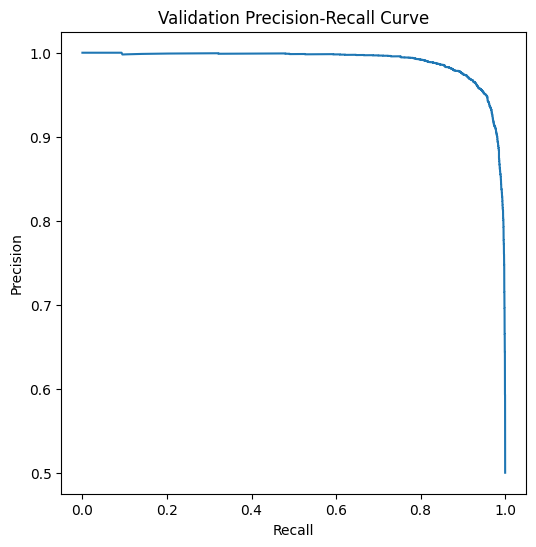

In [66]:
precision, recall, pr_thresholds = precision_recall_curve(val_y_true, val_y_prob)

plt.figure(figsize=(6, 6))
plt.plot(recall, precision)
plt.title("Validation Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()